In [9]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

In [10]:
# Carregar o dataset Breast Cancer
cancer = load_breast_cancer()
X = cancer.data
y = cancer.target

In [11]:
# Dividir entre treino e teste (70/30)
# stratify=y garante que a proporção de casos malignos seja igual em ambos os conjuntos
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [12]:
# Criar o modelo Naive Bayes (Gaussiano)
modelo_nb = GaussianNB()

In [13]:
# Treinar o modelo
modelo_nb.fit(X_train, y_train)

GaussianNB()

In [14]:
# Fazer previsões
y_pred = modelo_nb.predict(X_test)

In [15]:
# Avaliar o modelo
print("=== RESULTADOS - NAIVE BAYES NO BREAST CANCER ===\n")
print(f"Acurácia: {accuracy_score(y_test, y_pred):.4f}")

# Exibir o relatório com os nomes das classes (Malignant, Benign)
print("\nRelatório de Classificação:\n",
      classification_report(y_test, y_pred, target_names=cancer.target_names))

=== RESULTADOS - NAIVE BAYES NO BREAST CANCER ===

Acurácia: 0.9474

Relatório de Classificação:
               precision    recall  f1-score   support

   malignant       0.97      0.89      0.93        64
      benign       0.94      0.98      0.96       107

    accuracy                           0.95       171
   macro avg       0.95      0.94      0.94       171
weighted avg       0.95      0.95      0.95       171



In [16]:
# Gráfico Matriz de Confusão
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred)

<Figure size 600x400 with 0 Axes>

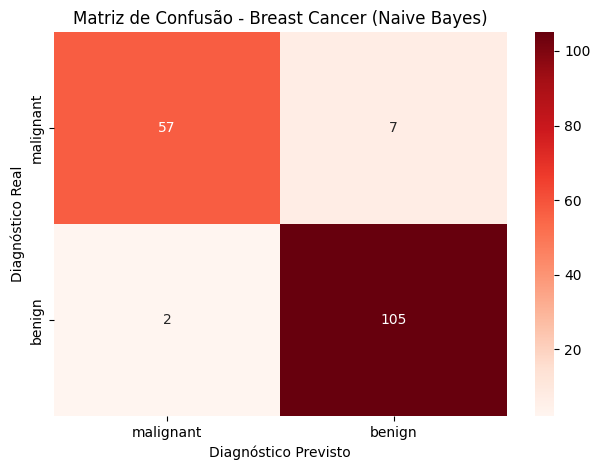

In [17]:
# Criar gráfico de calor
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=cancer.target_names,
            yticklabels=cancer.target_names)

plt.title('Matriz de Confusão - Breast Cancer (Naive Bayes)')
plt.ylabel('Diagnóstico Real')
plt.xlabel('Diagnóstico Previsto')
plt.tight_layout()
plt.show()